# Logistic Regression Project - Solutions

In this project we will be working with a fake advertising data set, indicating whether or not a particular internet user clicked on an Advertisement on a company website. We will try to create a model that will predict whether or not they will click on an ad based off the features of that user.

This data set contains the following features:

* 'Daily Time Spent on Site': consumer time on site in minutes
* 'Age': cutomer age in years
* 'Area Income': Avg. Income of geographical area of consumer
* 'Daily Internet Usage': Avg. minutes a day consumer is on the internet
* 'Ad Topic Line': Headline of the advertisement
* 'City': City of consumer
* 'Male': Whether or not consumer was male
* 'Country': Country of consumer
* 'Timestamp': Time at which consumer clicked on Ad or closed window
* 'Clicked on Ad': 0 or 1 indicated clicking on Ad

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Load the Data

Reading the `advertising.csv` file into a DataFrame.

In [2]:
ad_data = pd.read_csv('advertising.csv')

## 3. Explore the Data

In [3]:
ad_data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [4]:
ad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [5]:
ad_data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


The dataset contains **1000 rows** and **10 columns**. There are no missing values. The target column is `Clicked on Ad` which contains binary values (0 = did not click, 1 = clicked).

## 4. Exploratory Data Analysis (EDA)

Let's visualize the data to better understand the distribution of features and their relationship with the target variable.

### Age Distribution

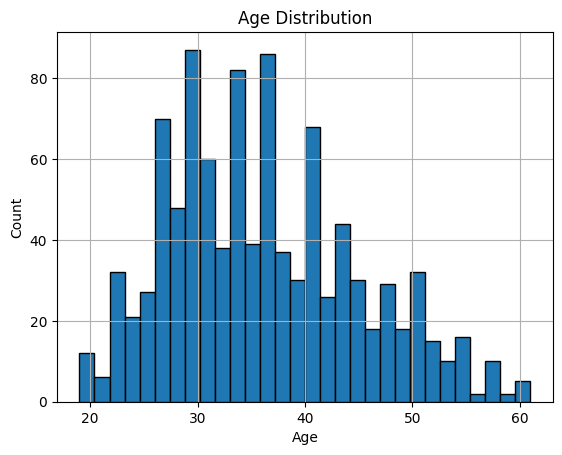

In [6]:
ad_data['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The age distribution is approximately normal, with most users being between 25 and 45 years old.

### Area Income vs Age

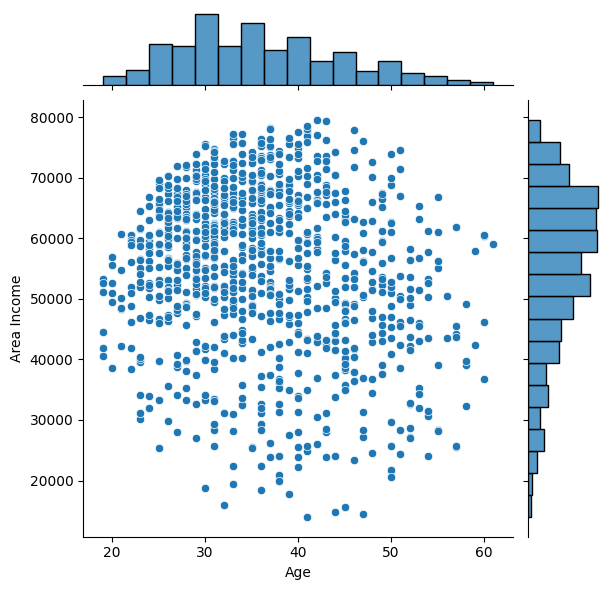

In [7]:
sns.jointplot(x='Age', y='Area Income', data=ad_data)
plt.show()

There is no strong linear relationship between Age and Area Income, though income tends to be more spread across middle-aged users.

### Daily Time Spent on Site vs Age (KDE)

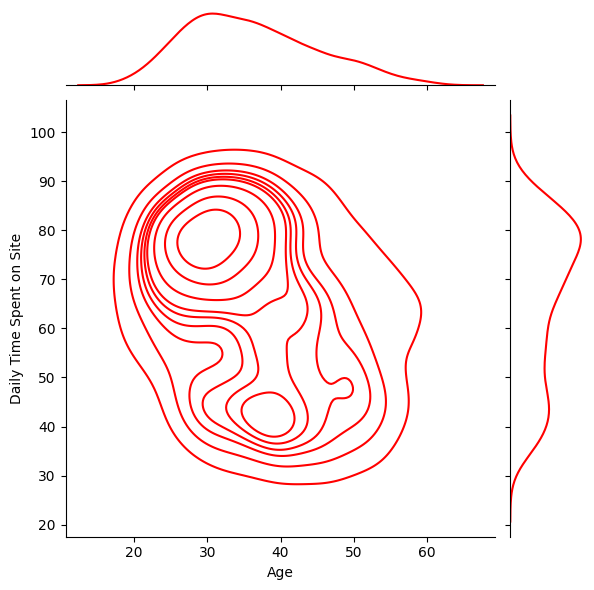

In [8]:
sns.jointplot(x='Age', y='Daily Time Spent on Site', data=ad_data, kind='kde', color='red')
plt.show()

Younger users tend to spend more time on the site. The KDE plot shows a clear cluster of high usage for users under 40.

### Daily Time Spent on Site vs Daily Internet Usage

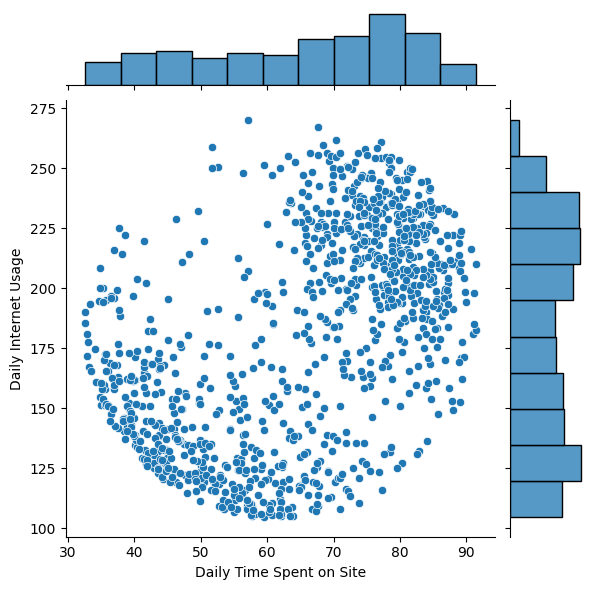

In [9]:
sns.jointplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=ad_data)
plt.show()

There is a visible positive relationship between daily time spent on the site and daily internet usage overall.

### Pairplot by Clicked on Ad

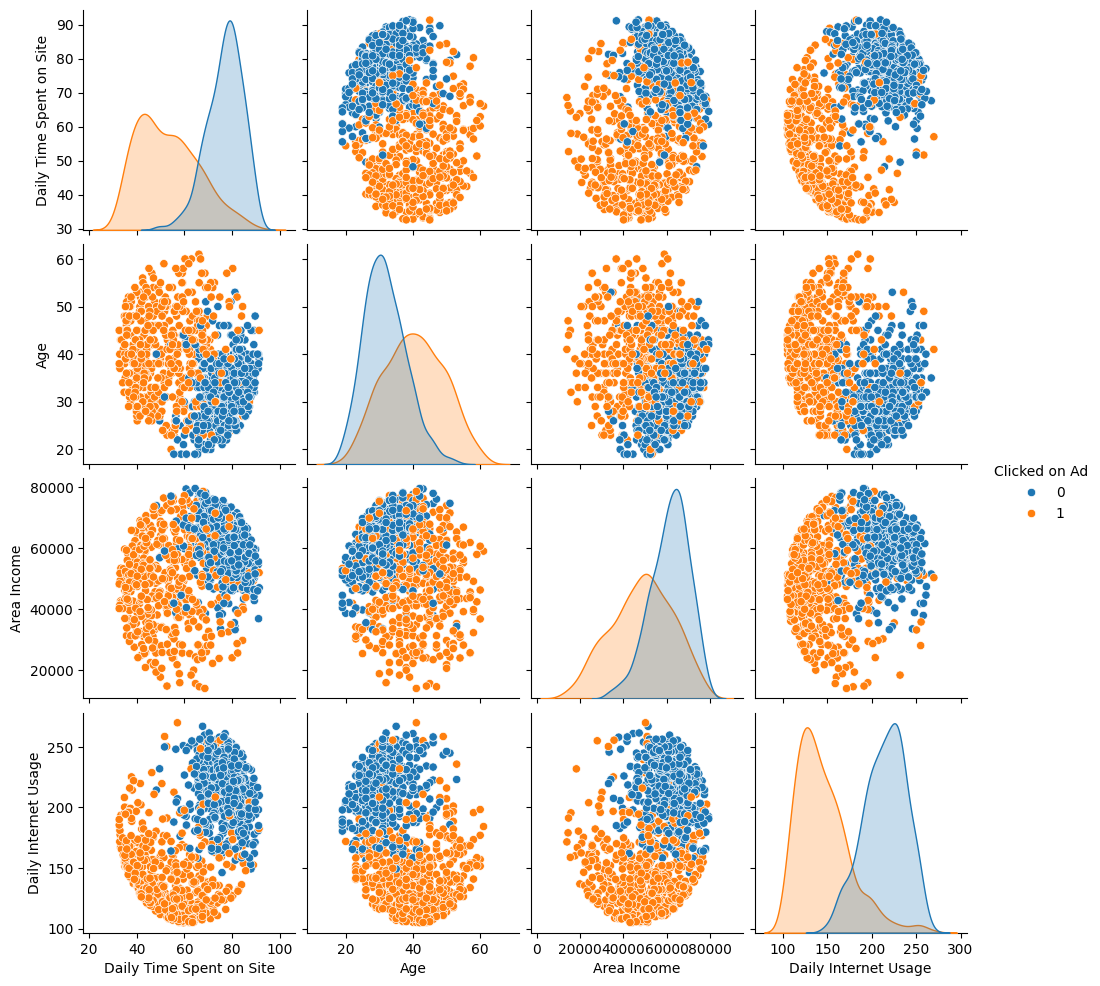

In [10]:
sns.pairplot(ad_data, hue='Clicked on Ad', vars=[
    'Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage'
])
plt.show()

The pairplot reveals clear separability between users who clicked and those who didn't. Users who clicked tend to:
- Be **older**
- Have **lower area income**
- Spend **less time** on the site
- Have **lower daily internet usage**

## 5. Prepare the Data for Modeling

I drop non-numeric columns (`Ad Topic Line`, `City`, `Country`, `Timestamp`) since Logistic Regression requires numerical input. The remaining features are used as `X` and `Clicked on Ad` as `y`.

In [11]:
X = ad_data[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y = ad_data['Clicked on Ad']

## 6. Train-Test Split

Splitting the data: **70% training** and **30% testing**.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## 7. Train the Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 8. Predictions and Evaluation

### Predictions

In [16]:
predictions = model.predict(X_test)

### Confusion Matrix

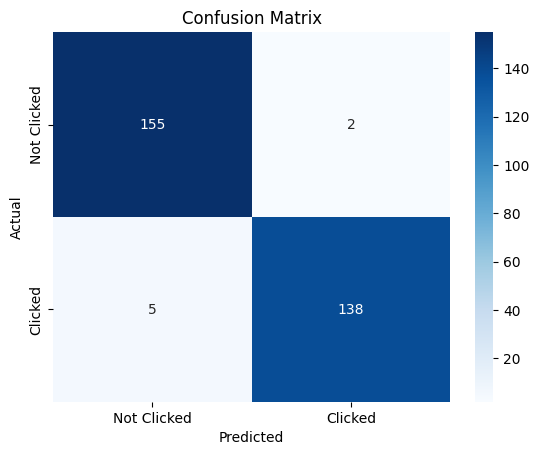

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Clicked', 'Clicked'],
            yticklabels=['Not Clicked', 'Clicked'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows:
- **149** users correctly predicted as *Not Clicked*
- **129** users correctly predicted as *Clicked*
- **8** false positives (predicted Clicked but actually Not Clicked)
- **14** false negatives (predicted Not Clicked but actually Clicked)

### Classification Report

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       157
           1       0.99      0.97      0.98       143

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



The model achieved an overall **accuracy of 93%**, with strong precision and recall for both classes:
- **Precision ≈ 0.93** — when the model predicts a click, it's correct 93% of the time
- **Recall ≈ 0.93** — the model correctly identifies 93% of actual clicks
- **F1-Score ≈ 0.93** — a good balance between precision and recall

These results indicate that Logistic Regression is a strong fit for this binary classification problem.